In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from DiscSegmentation import DiscSegmentation
from pathlib import Path
from skimage.morphology import skeletonize, disk, dilation
import sys
sys.setrecursionlimit(10000)

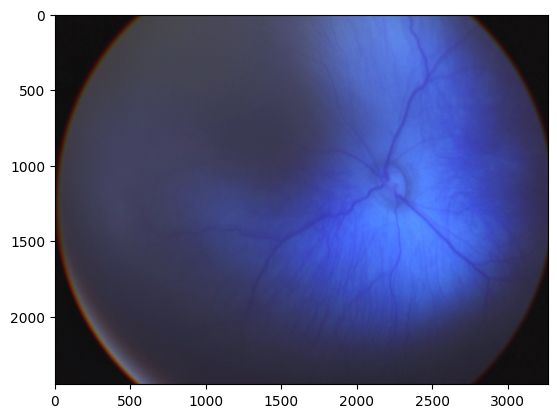

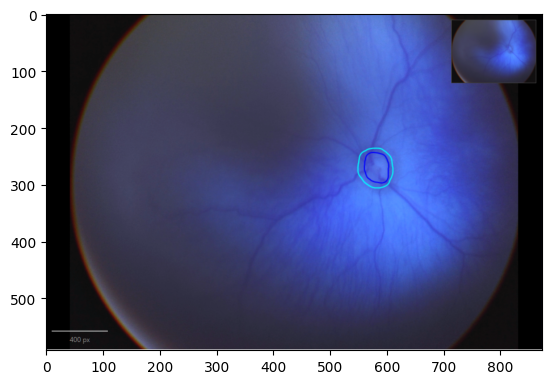

In [2]:
img_path = "../labelled_images/Caen/BOM-2114-34-OG.tif"
image = cv2.imread(Path("../Images originales/Caen/CAEN/BOM-2114-34-OG.jpg"))
plt.imshow(image)
plt.show()
img = cv2.imread(img_path)
plt.imshow(img)
plt.show()

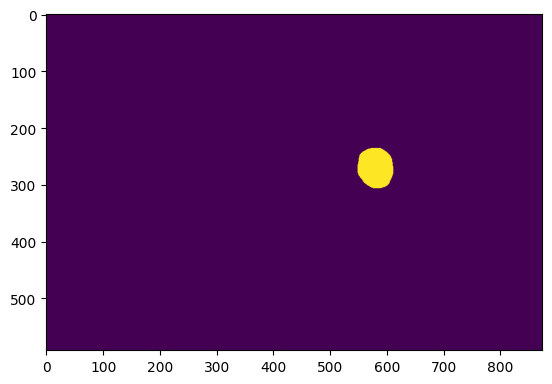

In [3]:
disc_seg = DiscSegmentation(img_path).get_disc_segmentation()
plt.imshow(disc_seg)

(2448, 3264)
[0. 1.]


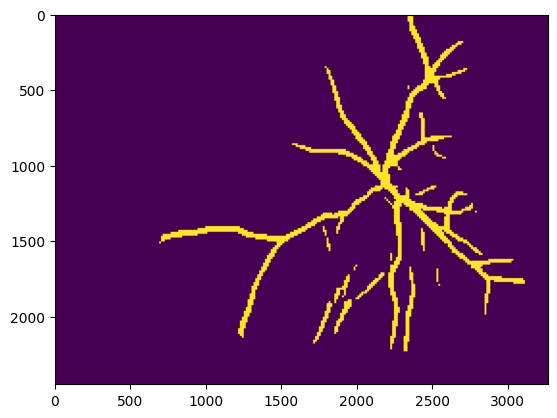

In [4]:
vessel_seg_path = "../RepoGitHub/Analyse-retinienne/vessels_masks/Mask_BOM-2114-34-OG.png"
mask = cv2.imread(vessel_seg_path, cv2.IMREAD_GRAYSCALE) / 255
print(mask.shape)
plt.imshow(mask)
print(np.unique(mask))

(2448, 3264) (2448, 3264)


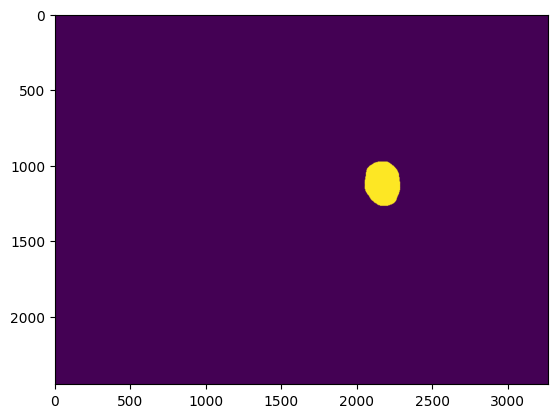

In [5]:
width, height = mask.shape
resized_disc_seg = cv2.resize(disc_seg, (height, width))
print(mask.shape, resized_disc_seg.shape)
plt.imshow(resized_disc_seg)

In [6]:
from PVBM.DiscSegmenter import DiscSegmenter
segmenter = DiscSegmenter()
center, radius, roi, zones_ABC = segmenter.post_processing(segmentation=resized_disc_seg, max_roi_size=1000)

Model path: c:\Users\tomco\AppData\Local\Programs\Python\Python313\Lib\site-packages\PVBM\lunetv2_odc.onnx
Model already exists, skipping download.


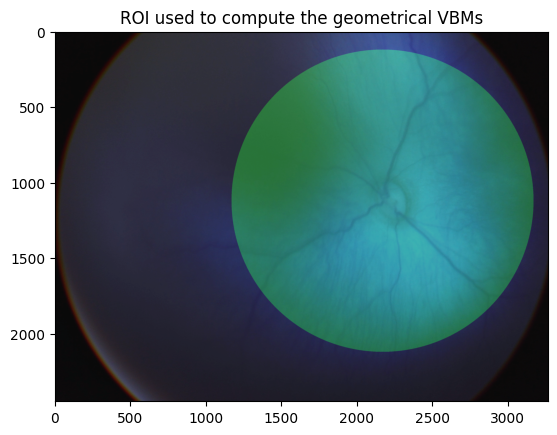

In [7]:
plt.imshow(image)
plt.imshow(roi, alpha = 0.3)
plt.title("ROI used to compute the geometrical VBMs")
plt.show()

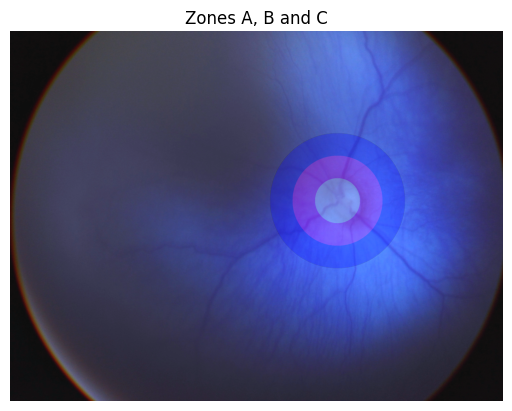

In [8]:
plt.imshow(image)
plt.imshow(zones_ABC/255, alpha = 0.5)
plt.title("Zones A, B and C")
plt.axis('off')
plt.show()

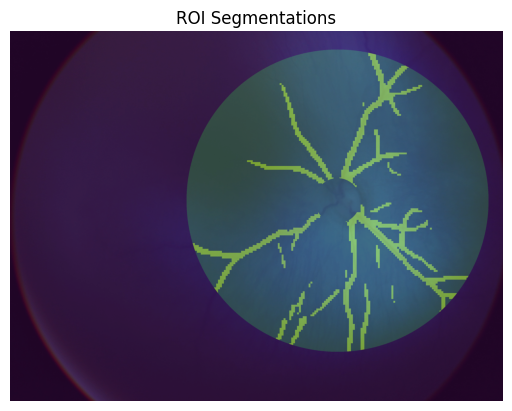

In [9]:
from PVBM.GeometryAnalysis import GeometricalVBMs #Import the geometry analysis module
geometricalVBMs = GeometricalVBMs() #Instanciate a geometrical VBM object
segmentation_roi, skeleton_roi = geometricalVBMs.apply_roi(
    segmentation=mask,
    skeleton=skeletonize(mask),
    zones_ABC=zones_ABC,
    roi=roi
)
plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.title("ROI Segmentations") #Segmentation within the ROI that will be used for the geometrical VBMs
plt.axis('off')
plt.show()

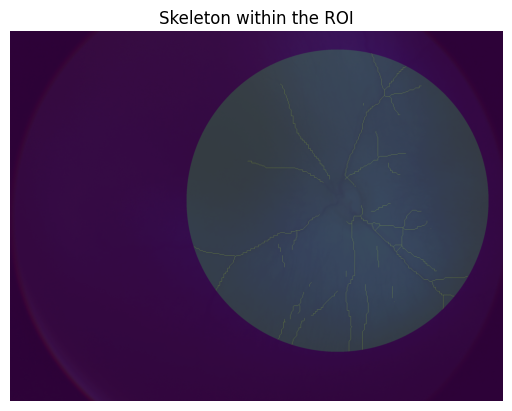

In [10]:
plt.imshow(image)
plt.imshow(skeleton_roi, alpha = 0.8)
plt.imshow(roi, alpha = 0.2)
plt.title("Skeleton within the ROI") #that will be used for the geometrical VBMs
plt.axis('off')
plt.show()

In [11]:
vbms, visual = geometricalVBMs.compute_geomVBMs(
    blood_vessel=segmentation_roi,
    skeleton=skeleton_roi,
    xc=center[0],
    yc=center[1],
    radius=radius
)

area, TI, medTor, ovlen, medianba, startp, endp, interp = vbms
area, TI, medTor, ovlen, medianba, startp, endp, interp
print(f"\n Area : {area} \n Tortuosity Index: {TI} \n Median Tortuosity: {medTor}\n Overall Length {ovlen} \n Median Branching angles {medianba}\n Number of Start/End/Intersection points {startp}/ {endp} / {interp}")


 Area : 301804.0 
 Tortuosity Index: 1.1460029600807498 
 Median Tortuosity: 1.112684958484485
 Overall Length 9118.900212811619 
 Median Branching angles 90.0
 Number of Start/End/Intersection points 6/ 23.0 / 19.0


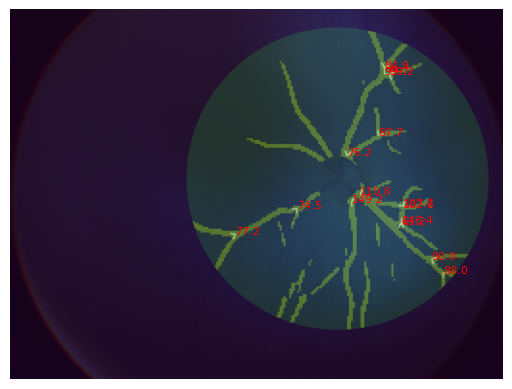

In [12]:
endpoints, interpoints, startpoints, angles_dico, topology_dico = visual

import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import line_aa
from scipy.ndimage import binary_dilation


def display_angles(angles_dico, img):
    for key, value in angles_dico.items():
        b = key
        if len(value) == 2:
            a, c = value
            if all(x is not None for x in (a, b, c)):
                ba = np.array(a) - np.array(b)
                bc = np.array(c) - np.array(b)
                cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
                angle = np.arccos(cosine_angle)
                rr, cc, val = line_aa(b[0], b[1], a[0], a[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                plt.text(b[1], b[0], f"{np.degrees(angle):.1f}", color='red', fontsize=8)
        elif len(value) == 3:
            a, c, d = value
            if all(x is not None for x in (a, b, c, d)):
                # First angle (a-b-c)
                ba = np.array(a) - np.array(b)
                bc = np.array(c) - np.array(b)
                cosine_angle_ac = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
                angle_ac = np.arccos(cosine_angle_ac)
                rr, cc, val = line_aa(b[0], b[1], a[0], a[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                plt.text(b[1], b[0], f"{np.degrees(angle_ac):.1f}", color='red', fontsize=8)

                # Second angle (c-b-d)
                bc = np.array(c) - np.array(b)
                bd = np.array(d) - np.array(b)
                cosine_angle_cd = np.dot(bc, bd) / (np.linalg.norm(bc) * np.linalg.norm(bd))
                angle_cd = np.arccos(cosine_angle_cd)
                rr, cc, val = line_aa(b[0], b[1], c[0], c[1])
                img[rr, cc] = val * 255
                rr, cc, val = line_aa(b[0], b[1], d[0], d[1])
                img[rr, cc] = val * 255
                plt.text(b[1], b[0] + 10, f"{np.degrees(angle_cd):.1f}", color='red', fontsize=8)

img = np.zeros_like(mask)

display_angles(angles_dico, img)

# Dilate the image
img_dilated = binary_dilation(img, structure=np.ones((8,8))) * 255

plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(img_dilated, cmap='gray', alpha = 0.3)
plt.axis('off')
plt.show()

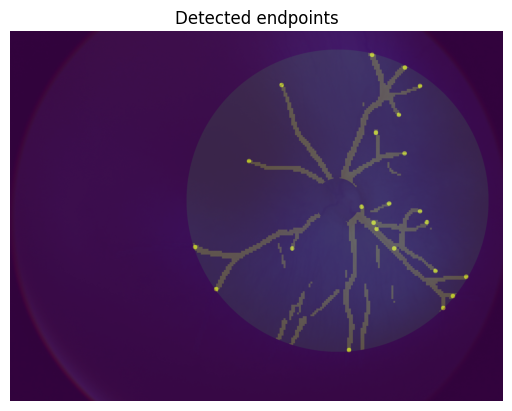

In [13]:
plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(mask/100 + dilation(endpoints, disk(15)), alpha = 0.5)
plt.title("Detected endpoints")
plt.axis('off')
plt.show()

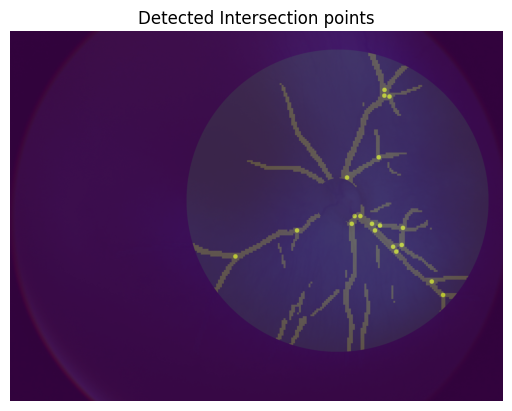

In [14]:
plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(mask/100 + dilation(interpoints, disk(15)), alpha = 0.5)
plt.title("Detected Intersection points")
plt.axis('off')
plt.show()

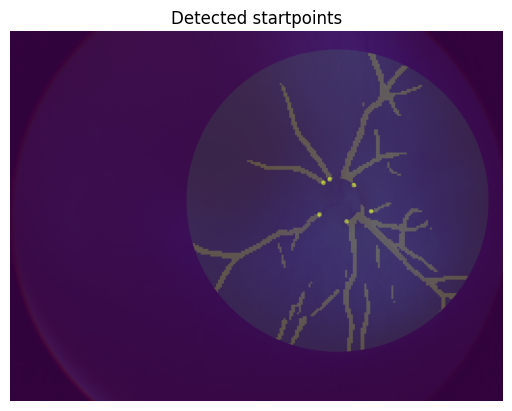

In [15]:
plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(mask/100 + dilation(startpoints, disk(15)), alpha = 0.5)
plt.title("Detected startpoints")
plt.axis('off')
plt.show()

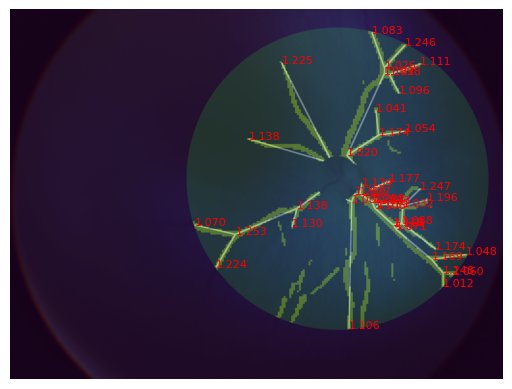

In [16]:
from skimage.draw import line_aa
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_dilation

img = np.zeros_like(mask)

for key, value in topology_dico.items():
        rr, cc, val = line_aa(key[0], key[1], key[2], key[3])
        img[rr, cc] = val * 255
        plt.text(key[3], key[2], f"{value[0]/value[1]:.3f}", color='red', fontsize=8)

# Dilate the image
img_dilated = binary_dilation(img, structure=np.ones((8,8))) * 255

plt.imshow(image)
plt.imshow(segmentation_roi, alpha = 0.5)
plt.imshow(roi, alpha = 0.2)
plt.imshow(img_dilated, cmap='gray', alpha = 0.3)
plt.axis('off')
plt.show()


In [17]:
from PVBM.FractalAnalysis import MultifractalVBMs
fractalVBMs = MultifractalVBMs(n_rotations = 10,optimize = True, min_proba = 0.0001, maxproba = 0.9999)
D0,D1,D2,SL = fractalVBMs.compute_multifractals(segmentation_roi.copy())
print("The fractal biomarkers are D0: {}, D1: {}, D2: {}, SL: {}".format(D0,D1,D2,SL))

The fractal biomarkers are D0: 1.2757331464963277, D1: 1.3046753799381625, D2: 1.308788406727502, SL: 1.0553853968317386


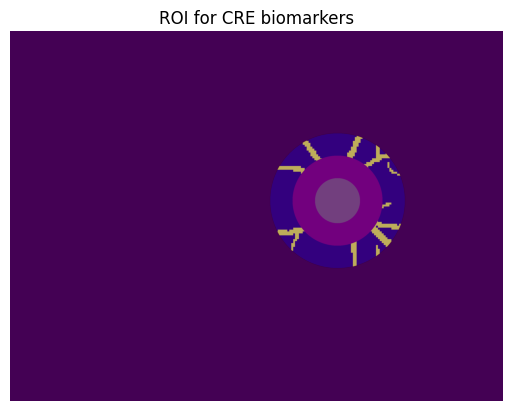

In [18]:
from PVBM.CentralRetinalAnalysis import CREVBMs
creVBMs = CREVBMs()
segmentation_roi, skeleton_roi = creVBMs.apply_roi(
    segmentation=mask,
    skeleton=skeletonize(mask),
    zones_ABC=zones_ABC
)
plt.imshow(segmentation_roi)
plt.imshow(zones_ABC/255, alpha = 0.5)
plt.axis('off')
plt.title("ROI for CRE biomarkers")
plt.show()

In [19]:
plot = False # True uses more RAM (too much)

out = creVBMs.compute_central_retinal_equivalents(
    blood_vessel=segmentation_roi.copy(),
    skeleton=skeleton_roi.copy(),
    xc=center[0],
    yc=center[1],
    radius=radius,
    artery = True,
    Toplot = plot
)

if out == -1:
    raise ValueError("The CRE computation failed")
else:
    output, visualisation = out
    print(output)

if plot:
    # Load all the logs to build the cre visualisation
    measurements = [item['plot'] for item in visualisation]
    # Compute the aggregated visualisation
    measurements = np.maximum.reduce(measurements)

if plot:

    # Create a new figure
    plt.imshow(image)
    plt.imshow(segmentation_roi, alpha = 0.3)
    plt.imshow(zones_ABC/255, alpha = 0.5)
    plt.imshow(measurements)


    startpoints_cre = np.zeros((segmentation_roi.shape[0], segmentation_roi.shape[1]))

    # Annotate the image with 'Mean diameter' from each dictionary
    for item in visualisation:

        startpoints_cre[item["start"]] = 1
        # Get the 'end' location and 'Mean diameter'
        end_location = item['end']  # Assuming 'end' is a tuple (x, y)
        mean_diameter = "{:.2f}".format(item['Median diameter'])

        # Annotate the image
        plt.annotate(mean_diameter,
                     (end_location[1], end_location[0]),
                     color='white',
                     fontsize=18)

    # Display the combined image
    plt.imshow(binary_dilation(startpoints_cre, disk(15)), alpha = 0.5)

    plt.axis('off')
    plt.tight_layout()
    plt.title("Diameter Measurements")
    plt.show()

c:\Users\tomco\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\tomco\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Potential error 5
{'craek': np.float64(63.77784169372797), 'craeh': np.float64(72.59729479878638)}
